In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('/home/davian/Projects/ML-TEMPLATE/ml/regression/data/raw/BostonHousing.csv')

In [5]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [ ]:
from preprocessing.cleaning import limpieza
from preprocessing.split_data import dividir_datos

df = limpieza(df)
x_train, x_test, y_train, y_test = dividir_datos(df, target=TARGET)

In [ ]:
from preprocessing.pipeline import estandarizar

x_train_prep, x_test_prep, _ = estandarizar(x_train, x_test)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=10)
rf_model.fit(x_train_prep, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [8]:
rf_model.feature_importances_

array([4.09789916e-02, 1.52562503e-03, 5.30251775e-03, 4.31818284e-04,
       2.31205231e-02, 5.72220672e-01, 1.56699397e-02, 4.93557490e-02,
       2.75070498e-03, 1.43818813e-02, 1.77209816e-02, 1.66336292e-02,
       2.39906966e-01])

In [9]:
feature_importance_df = pd.DataFrame({
    'feature': list(x_train),
    'importance': rf_model.feature_importances_
}).sort_values(by= 'importance', ascending=False)

feature_importance_df

,feature,importance
5,Nº habitaciones,0.572221
12,Prop. bajos recursos,0.239907
7,Dis. centro empleo,0.049356
0,Criminalidad,0.040979
4,Contaminación,0.023121
10,Prop. alumno/maestro,0.017721
11,Prop. población afroamericana,0.016634
6,Edad,0.015670
9,Impuestos,0.014382
2,Comercio,0.005303


<Axes: xlabel='importance', ylabel='feature'>

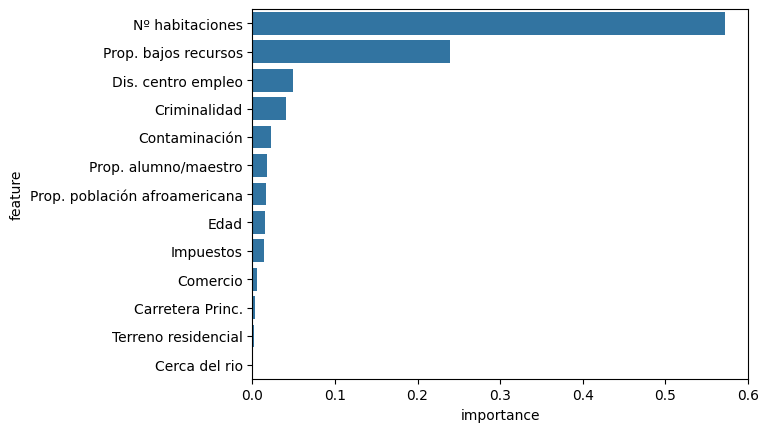

In [11]:
import seaborn as sns
sns.barplot(data=feature_importance_df, x='importance', y='feature')